In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("diabetes_prediction_dataset.csv")

In [2]:
print(df.head())

print(df.shape)

print(df.dtypes)

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  
(100000, 9)
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 

In [3]:
print(df.describe())

                 age  hypertension  heart_disease            bmi  \
count  100000.000000  100000.00000  100000.000000  100000.000000   
mean       41.885856       0.07485       0.039420      27.320767   
std        22.516840       0.26315       0.194593       6.636783   
min         0.080000       0.00000       0.000000      10.010000   
25%        24.000000       0.00000       0.000000      23.630000   
50%        43.000000       0.00000       0.000000      27.320000   
75%        60.000000       0.00000       0.000000      29.580000   
max        80.000000       1.00000       1.000000      95.690000   

         HbA1c_level  blood_glucose_level       diabetes  
count  100000.000000        100000.000000  100000.000000  
mean        5.527507           138.058060       0.085000  
std         1.070672            40.708136       0.278883  
min         3.500000            80.000000       0.000000  
25%         4.800000           100.000000       0.000000  
50%         5.800000           14

In [4]:
diabetic = df[df["diabetes"] == 1]

print(diabetic.head())

    gender   age  hypertension  heart_disease smoking_history    bmi  \
6   Female  44.0             0              0           never  19.31   
26    Male  67.0             0              1     not current  27.32   
38    Male  50.0             1              0         current  27.32   
40    Male  73.0             0              0          former  25.91   
53  Female  53.0             0              0          former  27.32   

    HbA1c_level  blood_glucose_level  diabetes  
6           6.5                  200         1  
26          6.5                  200         1  
38          5.7                  260         1  
40          9.0                  160         1  
53          7.0                  159         1  


In [5]:
female = df[df["gender"] == "Female"]

print(female.head())

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
3  Female  36.0             0              0         current  23.45   
5  Female  20.0             0              0           never  27.32   
6  Female  44.0             0              0           never  19.31   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
3          5.0                  155         0  
5          6.6                   85         0  
6          6.5                  200         1  


In [6]:
sorted_df = df.sort_values(
    by="blood_glucose_level",
    ascending=False
)

print(sorted_df.head())

       gender   age  hypertension  heart_disease smoking_history    bmi  \
99938    Male  55.0             0              1          former  30.42   
41052  Female  66.0             1              0           never  35.30   
96043    Male  43.0             1              0          former  35.39   
95961  Female  45.0             0              0         current  50.05   
95956    Male  72.0             0              0          former  27.32   

       HbA1c_level  blood_glucose_level  diabetes  
99938          6.2                  300         1  
41052          6.2                  300         1  
96043          9.0                  300         1  
95961          6.0                  300         1  
95956          7.5                  300         1  


In [7]:
print("Mean :", df["blood_glucose_level"].mean())

print("Median :", df["blood_glucose_level"].median())

print("Mode :")

print(df["blood_glucose_level"].mode())

print("Standard Deviation :", df["blood_glucose_level"].std())

Mean : 138.05806
Median : 140.0
Mode :
0    130
Name: blood_glucose_level, dtype: int64
Standard Deviation : 40.70813604870113


In [8]:
gender_avg = df.groupby("gender")["blood_glucose_level"].mean()

print(gender_avg.sort_values(ascending=False))

gender
Other     139.444444
Male      138.890031
Female    137.468951
Name: blood_glucose_level, dtype: float64


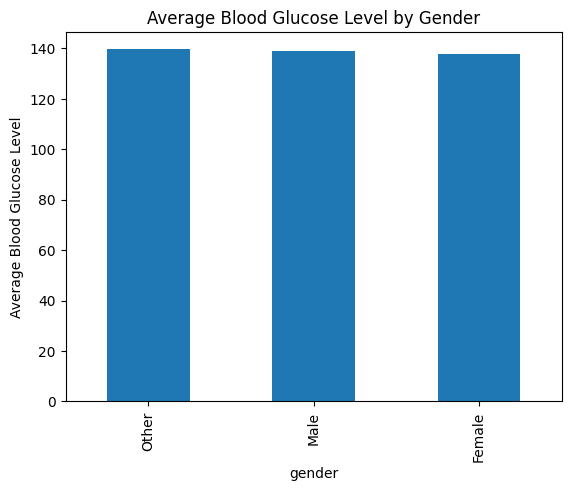

In [9]:
gender_avg.sort_values(ascending=False).plot(kind="bar")

plt.title("Average Blood Glucose Level by Gender")

plt.ylabel("Average Blood Glucose Level")

plt.show()

In [10]:
corr = df[
    [
        "age",
        "bmi",
        "HbA1c_level",
        "blood_glucose_level",
        "diabetes"
    ]
].corr()

print(corr)

                          age       bmi  HbA1c_level  blood_glucose_level  \
age                  1.000000  0.337396     0.101354             0.110672   
bmi                  0.337396  1.000000     0.082997             0.091261   
HbA1c_level          0.101354  0.082997     1.000000             0.166733   
blood_glucose_level  0.110672  0.091261     0.166733             1.000000   
diabetes             0.258008  0.214357     0.400660             0.419558   

                     diabetes  
age                  0.258008  
bmi                  0.214357  
HbA1c_level          0.400660  
blood_glucose_level  0.419558  
diabetes             1.000000  


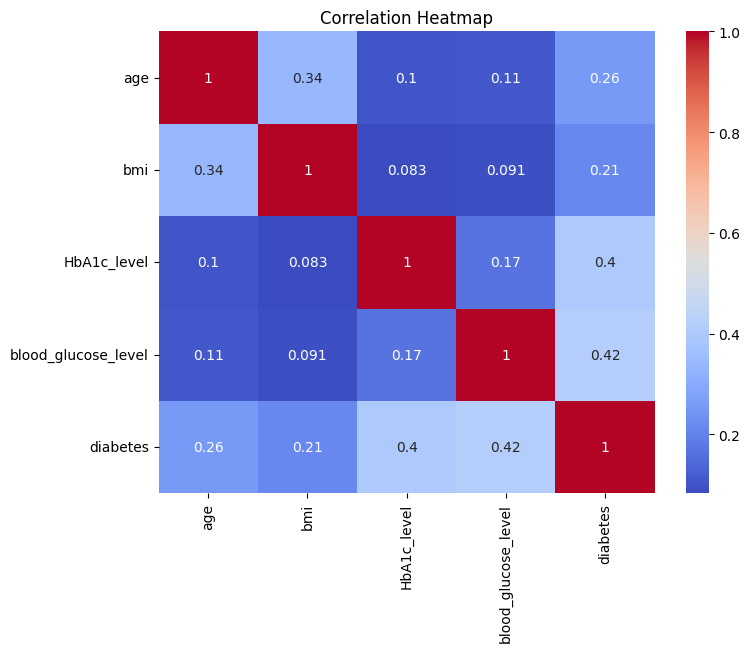

In [11]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

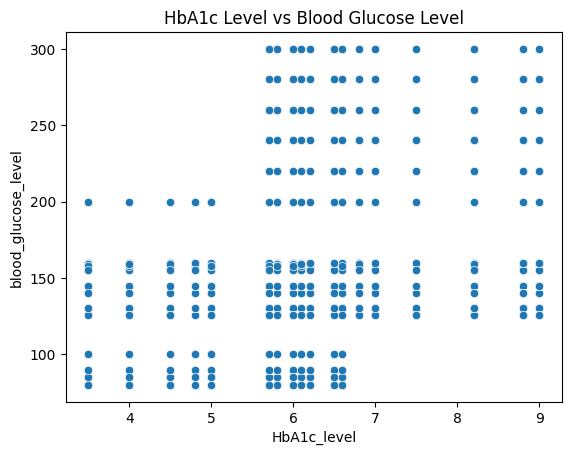

In [12]:
sns.scatterplot(
    data=df,
    x="HbA1c_level",
    y="blood_glucose_level"
)

plt.title("HbA1c Level vs Blood Glucose Level")

plt.show()